In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import joblib

os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device utilisé : {DEVICE}")

✅ Device utilisé : cpu


In [5]:
# Charger les données préparées dans le notebook 1
X_train = np.load('data/processed/X_train.npy')
X_test  = np.load('data/processed/X_test.npy')
y_train = np.load('data/processed/y_train.npy')
y_test  = np.load('data/processed/y_test.npy')

print(f"📊 Données chargées :")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   y_train — Normal: {(y_train==0).sum():,}  Attaque: {(y_train==1).sum():,}")
print(f"   y_test  — Normal: {(y_test==0).sum():,}  Attaque: {(y_test==1).sum():,}")

📊 Données chargées :
   X_train : (204822, 71)
   X_test  : (44617, 71)
   y_train — Normal: 102,411  Attaque: 102,411
   y_test  — Normal: 19,014  Attaque: 25,603


In [6]:
print("[Isolation Forest] Entraînement...")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train)

joblib.dump(iso_forest, 'models/isolation_forest.pkl')
print("✅ Modèle entraîné et sauvegardé → models/isolation_forest.pkl")

[Isolation Forest] Entraînement...
✅ Modèle entraîné et sauvegardé → models/isolation_forest.pkl


In [7]:
print("[Isolation Forest] Évaluation...")

# -1 = anomalie → 1 (attaque) ; +1 = normal → 0
raw_preds = iso_forest.predict(X_test)
y_pred_if = np.where(raw_preds == -1, 1, 0)

# Score d'anomalie (plus haut = plus anormal)
scores_if = -iso_forest.decision_function(X_test)
auc_if = roc_auc_score(y_test, scores_if)

print(classification_report(y_test, y_pred_if, target_names=["Normal", "Attaque"]))
print(f"AUC-ROC : {auc_if:.4f}")

[Isolation Forest] Évaluation...
              precision    recall  f1-score   support

      Normal       0.40      0.90      0.56     19014
     Attaque       0.06      0.00      0.01     25603

    accuracy                           0.39     44617
   macro avg       0.23      0.45      0.28     44617
weighted avg       0.21      0.39      0.24     44617

AUC-ROC : 0.3538


In [8]:
# Fonctions de visualisation réutilisables pour tous les modèles

def plot_roc(y_true, scores, model_name, color="#534AB7"):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc = roc_auc_score(y_true, scores)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, color=color, lw=2, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire")
    plt.xlabel("Taux de faux positifs (FPR)")
    plt.ylabel("Taux de vrais positifs (TPR)")
    plt.title(f"{model_name} — Courbe ROC")
    plt.legend()
    plt.tight_layout()
    fname = model_name.lower().replace(" ", "_")
    plt.savefig(f"plots/{fname}_roc.png", dpi=150, bbox_inches='tight')
    plt.show()

def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Attaque"])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name} — Matrice de confusion")
    plt.tight_layout()
    fname = model_name.lower().replace(" ", "_")
    plt.savefig(f"plots/{fname}_cm.png", dpi=150, bbox_inches='tight')
    plt.show()

print("✅ Fonctions de visualisation prêtes")

✅ Fonctions de visualisation prêtes


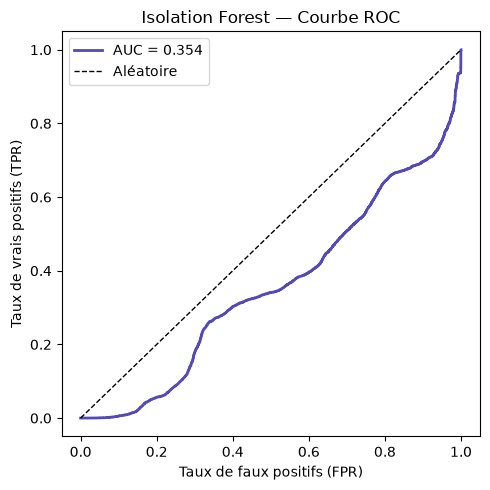

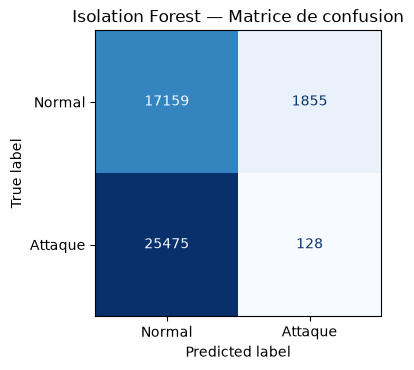

In [9]:
plot_roc(y_test, scores_if, "Isolation Forest", color="#534AB7")
plot_confusion(y_test, y_pred_if, "Isolation Forest")

In [10]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

print("✅ Classe Autoencoder définie")

✅ Classe Autoencoder définie


In [11]:
# Entraînement sur les données normales uniquement
print("[Autoencoder] Entraînement (40 epochs)...")

input_dim = X_train.shape[1]
tensor_train = torch.FloatTensor(X_train).to(DEVICE)
loader = DataLoader(TensorDataset(tensor_train), batch_size=256, shuffle=True)

ae_model = Autoencoder(input_dim).to(DEVICE)
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 40
losses = []

for epoch in range(1, epochs + 1):
    ae_model.train()
    epoch_loss = 0.0
    for (batch,) in loader:
        recon = ae_model(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    if epoch % 5 == 0:
        print(f"  Epoch {epoch:3d}/{epochs}  Loss: {avg_loss:.6f}")

torch.save(ae_model.state_dict(), 'models/autoencoder.pt')
print("\n✅ Autoencoder entraîné et sauvegardé → models/autoencoder.pt")

[Autoencoder] Entraînement (40 epochs)...
  Epoch   5/40  Loss: 0.032282
  Epoch  10/40  Loss: 0.022262
  Epoch  15/40  Loss: 0.014254
  Epoch  20/40  Loss: 0.013494
  Epoch  25/40  Loss: 0.016594
  Epoch  30/40  Loss: 0.009530
  Epoch  35/40  Loss: 0.017430
  Epoch  40/40  Loss: 0.010480

✅ Autoencoder entraîné et sauvegardé → models/autoencoder.pt


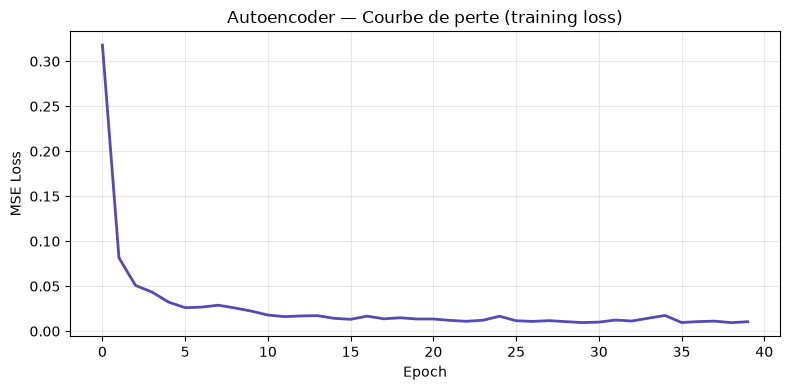

In [12]:
# Courbe de la perte d'entraînement
plt.figure(figsize=(8, 4))
plt.plot(losses, color="#534AB7", lw=2)
plt.title("Autoencoder — Courbe de perte (training loss)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/autoencoder_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print("[Autoencoder] Évaluation...")

ae_model.eval()
with torch.no_grad():
    tensor_test = torch.FloatTensor(X_test).to(DEVICE)
    recon_test = ae_model(tensor_test).cpu().numpy()

# Erreur de reconstruction par échantillon (MSE)
errors_ae = np.mean((X_test - recon_test) ** 2, axis=1)

# Seuil = 95e percentile des erreurs
threshold = np.percentile(errors_ae, 95)
print(f"Seuil de détection (p95) : {threshold:.6f}")

y_pred_ae = (errors_ae > threshold).astype(int)
auc_ae = roc_auc_score(y_test, errors_ae)

print(classification_report(y_test, y_pred_ae, target_names=["Normal", "Attaque"]))
print(f"AUC-ROC : {auc_ae:.4f}")

[Autoencoder] Évaluation...
Seuil de détection (p95) : 0.015264
              precision    recall  f1-score   support

      Normal       0.40      0.89      0.55     19014
     Attaque       0.04      0.00      0.01     25603

    accuracy                           0.38     44617
   macro avg       0.22      0.45      0.28     44617
weighted avg       0.19      0.38      0.24     44617

AUC-ROC : 0.2515


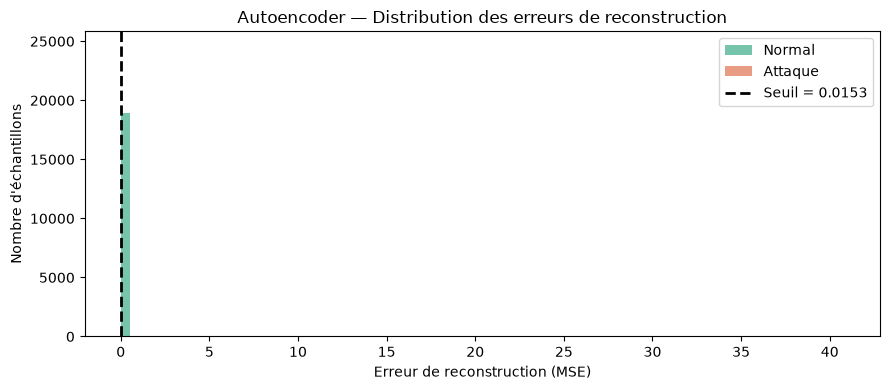

In [14]:
# Distribution des erreurs de reconstruction : normal vs attaque
plt.figure(figsize=(9, 4))
plt.hist(errors_ae[y_test == 0], bins=80, alpha=0.6, color="#1D9E75", label="Normal")
plt.hist(errors_ae[y_test == 1], bins=80, alpha=0.6, color="#D85A30", label="Attaque")
plt.axvline(threshold, color="black", linestyle="--", lw=2, label=f"Seuil = {threshold:.4f}")
plt.xlabel("Erreur de reconstruction (MSE)")
plt.ylabel("Nombre d'échantillons")
plt.title("Autoencoder — Distribution des erreurs de reconstruction")
plt.legend()
plt.tight_layout()
plt.savefig('plots/autoencoder_errors.png', dpi=150, bbox_inches='tight')
plt.show()

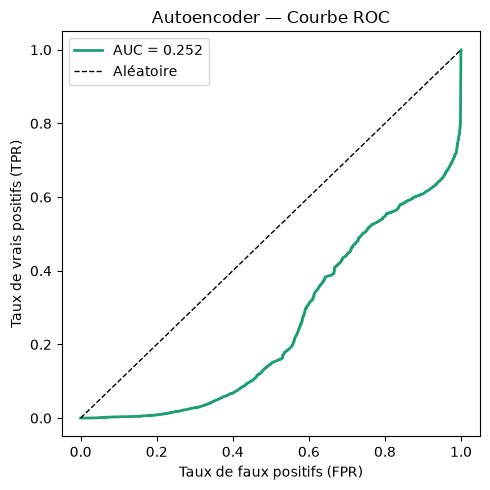

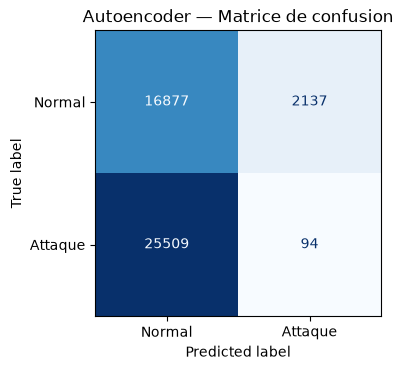

In [15]:
plot_roc(y_test, errors_ae, "Autoencoder", color="#1D9E75")
plot_confusion(y_test, y_pred_ae, "Autoencoder")

In [16]:
class LSTMDetector(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = self.classifier(h_n[-1])
        return out.squeeze(-1)


def build_sequences(X, y, seq_len=10):
    """Découpe X en fenêtres glissantes de taille seq_len."""
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i: i + seq_len])
        ys.append(y[i + seq_len - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

print("✅ Classe LSTMDetector et build_sequences() définies")

✅ Classe LSTMDetector et build_sequences() définies


In [17]:
print("[LSTM] Construction des séquences (window=10)...")

SEQ_LEN = 10
X_train_seq, y_train_seq = build_sequences(X_train, y_train, seq_len=SEQ_LEN)
print(f"   Train séquences : {X_train_seq.shape}")

[LSTM] Construction des séquences (window=10)...
   Train séquences : (204812, 10, 71)


In [18]:
print("[LSTM] Entraînement (30 epochs)...")

X_t = torch.FloatTensor(X_train_seq).to(DEVICE)
y_t = torch.FloatTensor(y_train_seq).to(DEVICE)
loader_lstm = DataLoader(TensorDataset(X_t, y_t), batch_size=128, shuffle=True)

lstm_model = LSTMDetector(input_dim=X_train_seq.shape[2]).to(DEVICE)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

epochs = 30
lstm_losses = []

for epoch in range(1, epochs + 1):
    lstm_model.train()
    total_loss = 0.0
    for xb, yb in loader_lstm:
        preds = lstm_model(xb)
        loss = criterion(preds, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg = total_loss / len(loader_lstm)
    lstm_losses.append(avg)
    if epoch % 5 == 0:
        print(f"  Epoch {epoch:3d}/{epochs}  Loss: {avg:.5f}")

torch.save(lstm_model.state_dict(), 'models/lstm_detector.pt')
print("\n✅ LSTM entraîné et sauvegardé → models/lstm_detector.pt")

[LSTM] Entraînement (30 epochs)...
  Epoch   5/30  Loss: 0.00245
  Epoch  10/30  Loss: 0.00163
  Epoch  15/30  Loss: 0.00118
  Epoch  20/30  Loss: 0.00074
  Epoch  25/30  Loss: 0.00050
  Epoch  30/30  Loss: 0.00039

✅ LSTM entraîné et sauvegardé → models/lstm_detector.pt


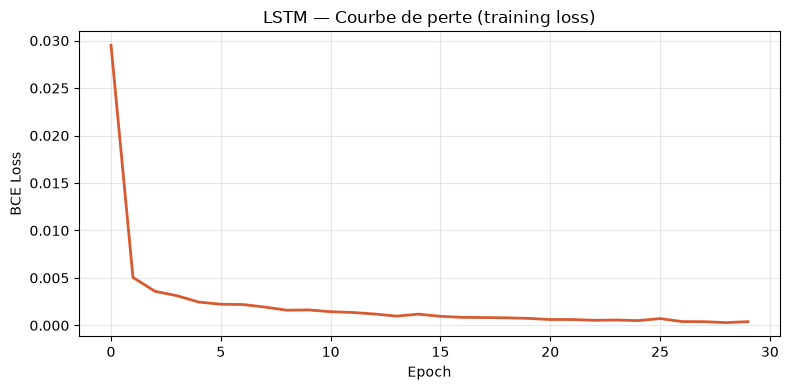

In [19]:
# Courbe de perte LSTM
plt.figure(figsize=(8, 4))
plt.plot(lstm_losses, color="#D85A30", lw=2)
plt.title("LSTM — Courbe de perte (training loss)")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/lstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
print("[LSTM] Évaluation...")

X_test_seq, y_test_seq = build_sequences(X_test, y_test, seq_len=SEQ_LEN)

lstm_model.eval()
with torch.no_grad():
    X_t_test = torch.FloatTensor(X_test_seq).to(DEVICE)
    logits = lstm_model(X_t_test).cpu().numpy()

scores_lstm = torch.sigmoid(torch.FloatTensor(logits)).numpy()
y_pred_lstm = (scores_lstm > 0.5).astype(int)
auc_lstm = roc_auc_score(y_test_seq, scores_lstm)

print(classification_report(y_test_seq, y_pred_lstm, target_names=["Normal", "Attaque"]))
print(f"AUC-ROC : {auc_lstm:.4f}")

[LSTM] Évaluation...
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19010
     Attaque       1.00      1.00      1.00     25597

    accuracy                           1.00     44607
   macro avg       1.00      1.00      1.00     44607
weighted avg       1.00      1.00      1.00     44607

AUC-ROC : 1.0000


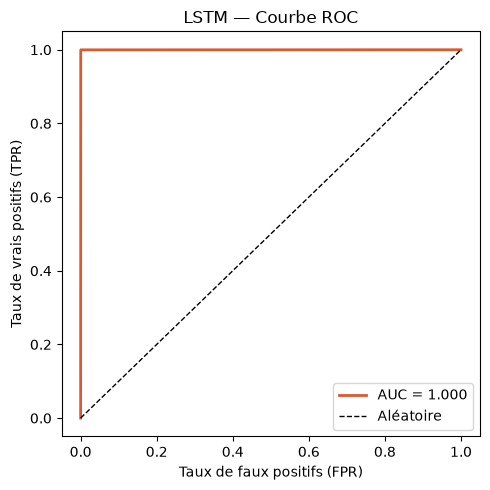

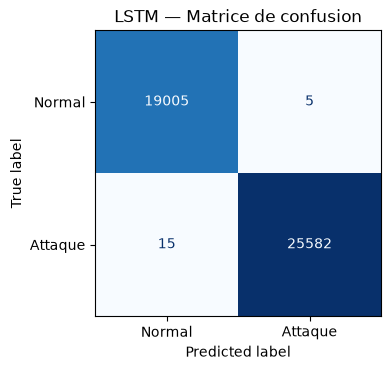

In [21]:
plot_roc(y_test_seq, scores_lstm, "LSTM", color="#D85A30")
plot_confusion(y_test_seq, y_pred_lstm, "LSTM")

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    "Isolation Forest": {
        "AUC-ROC":   auc_if,
        "Precision": precision_score(y_test, y_pred_if),
        "Recall":    recall_score(y_test, y_pred_if),
        "F1-score":  f1_score(y_test, y_pred_if),
    },
    "Autoencoder": {
        "AUC-ROC":   auc_ae,
        "Precision": precision_score(y_test, y_pred_ae),
        "Recall":    recall_score(y_test, y_pred_ae),
        "F1-score":  f1_score(y_test, y_pred_ae),
    },
    "LSTM": {
        "AUC-ROC":   auc_lstm,
        "Precision": precision_score(y_test_seq, y_pred_lstm),
        "Recall":    recall_score(y_test_seq, y_pred_lstm),
        "F1-score":  f1_score(y_test_seq, y_pred_lstm),
    },
}

results_df = pd.DataFrame(results).T.round(4)
print("=" * 50)
print("   COMPARAISON DES MODÈLES")
print("=" * 50)
print(results_df.to_string())
print("=" * 50)

results_df.to_csv('plots/model_comparison.csv')

   COMPARAISON DES MODÈLES
                  AUC-ROC  Precision  Recall  F1-score
Isolation Forest   0.3538     0.0645  0.0050    0.0093
Autoencoder        0.2515     0.0421  0.0037    0.0068
LSTM               1.0000     0.9998  0.9994    0.9996


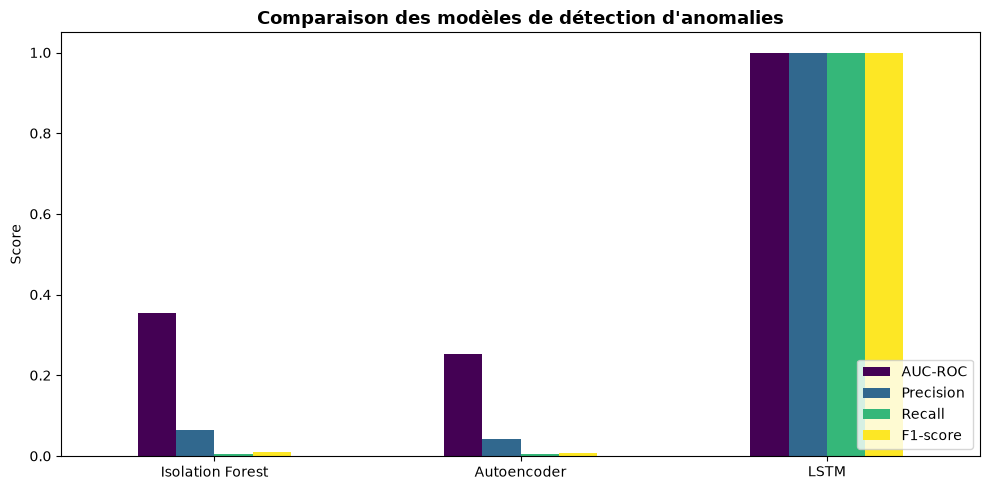


🏆 Meilleur modèle (AUC-ROC) : LSTM (1.0000)


In [23]:
# Graphique de comparaison
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='none')
ax.set_title("Comparaison des modèles de détection d'anomalies", fontsize=13, fontweight='bold')
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = results_df["AUC-ROC"].idxmax()
print(f"\n🏆 Meilleur modèle (AUC-ROC) : {best_model} ({results_df.loc[best_model, 'AUC-ROC']:.4f})")